# Notebook 19: Extended Weeks 1-6

Load raw attempt data and assessment grades.

Engineer features using attempts from weeks 1 to 6.

Train four models using 5-fold LOYOCV (2014-2018).

Grid search tries different settings and picks the one that performs best.

Balanced accuracy is used to choose the best threshold because it gives equal weight to predicting passes and fails.

Export results to Excel and save charts.

Results will be saved to: C:\Users\Nikita Danvill\OneDrive - University of Otago\Documents\INFO501\Nikita_Danvill_8887029_JupyterNotebooks_INFO501\Results
NOTEBOOK 19: EXTENDED WEEKS 1-6
  Feature window      : Weeks 1-6
  Include Practical 1 : False
  Methodology         : LOYOCV with balanced accuracy threshold calibration

STEP 1: LOADING RAW DATA
  All attempts loaded  : 14,338 rows
  Assessment records   : 1,154 student-cohort pairs
  Pass: 887  Fail: 267

STEP 2: ENGINEERING FEATURES (WEEKS 1-6)
  Attempts in window   : 7,405 (from 14,338 total)
  Feature matrix shape : (1154, 25)
  Students (unit of analysis): 1154
  Pass: 887  Fail: 267
  Total features       : 21
  Feature list: ['num_atmp_l1', 'num_atmp_l2', 'num_atmp_l3', 'num_atmp_l4', 'num_atmp_l5', 'num_atmp_l6', 'num_atmp_l7', 'num_atmp_l8', 'num_atmp_l11', 'wk_comp_l1', 'wk_comp_l2', 'wk_comp_l3', 'wk_comp_l4', 'wk_comp_l5', 'wk_comp_l6', 'wk_comp_l7', 'wk_comp_l8', 'total_attempts_6w', 'levels_completed_6w', 'efficienc

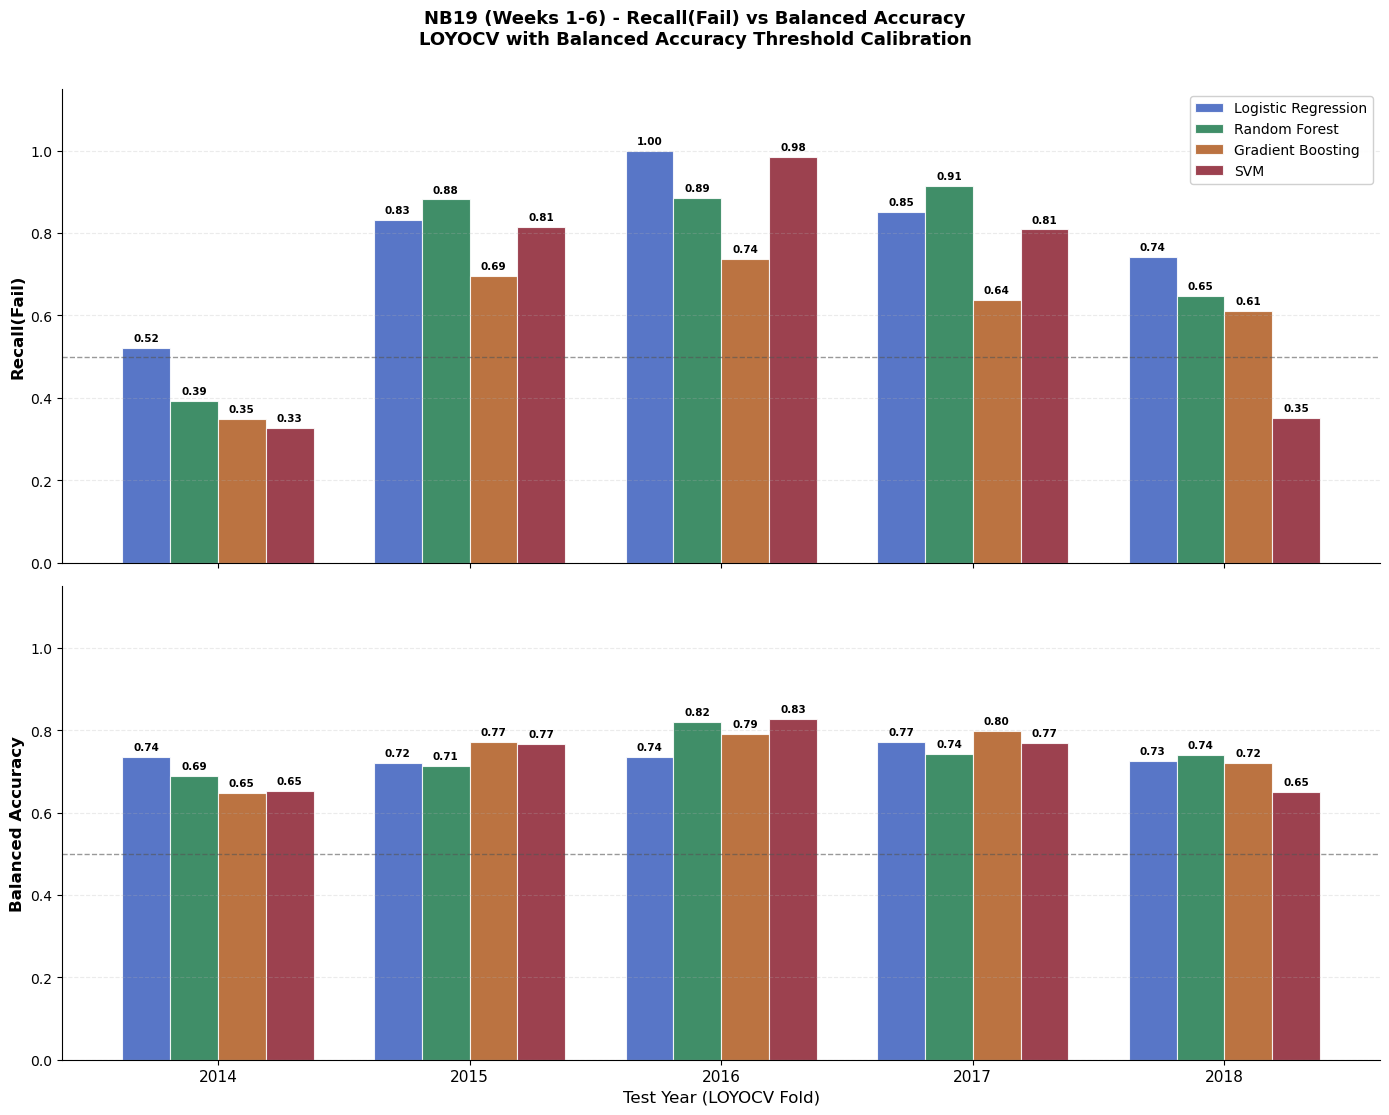

  ✓ Chart 1: Recall(Fail) vs Balanced Accuracy saved


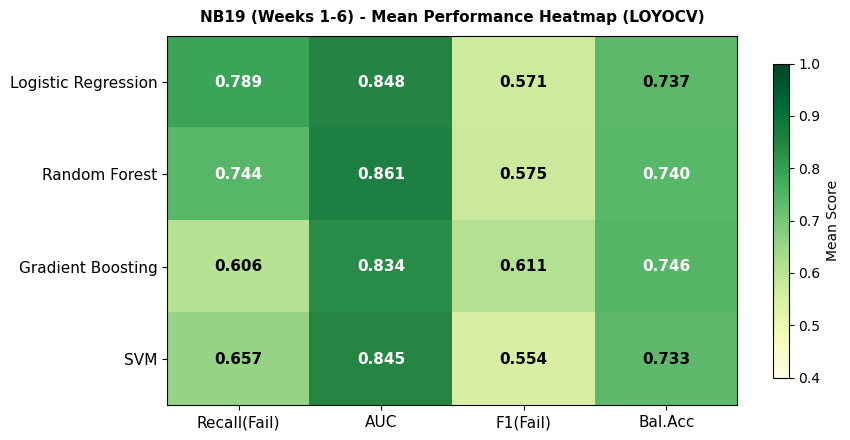

  ✓ Chart 2: Metrics heatmap saved

All NB19 visualizations saved.


,Model,Recall(Fail),Δ Recall,AUC,Δ AUC,F1(Fail),Δ F1,Bal.Acc,Δ Bal.Acc
0,Logistic Regression,0.789 (±0.176),-0.042319,0.848 (±0.036),0.000599,0.571 (±0.022),0.006632,0.737 (±0.020),0.001558
1,Random Forest,0.744 (±0.225),0.096643,0.861 (±0.028),0.046871,0.575 (±0.073),0.001712,0.740 (±0.049),0.008403
2,Gradient Boosting,0.606 (±0.152),0.107685,0.834 (±0.017),-0.019512,0.611 (±0.103),0.048025,0.746 (±0.062),0.035573
3,SVM,0.657 (±0.299),0.040569,0.845 (±0.034),0.012980,0.554 (±0.090),-0.032598,0.733 (±0.079),-0.006222



NOTEBOOK 19 COMPLETE


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 19: EXTENDED WEEKS 1-6 - FULL PIPELINE
# Feature engineering for weeks 1-6, LOYOCV, Balanced Accuracy threshold
# Mirrors NB13 methodology exactly, extended observation window
# ══════════════════════════════════════════════════════════════════════════════
import os, warnings
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.metrics import make_scorer
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.utils.dataframe import dataframe_to_rows
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# ── Configuration ──────────────────────────────────────────────────────────────
WEEK_CUTOFF          = 6
INCLUDE_PRACTICAL_1  = False
MASTERY_DATA_PATH = os.path.join(os.getcwd(), "mastery_data.xlsx")
RESULTS_DIR = os.path.join(os.getcwd(), "Results")
CHARTS_DIR  = os.path.join(os.getcwd(), "Charts")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR,  exist_ok=True)
OUTPUT_FILE          = os.path.join(RESULTS_DIR, "Notebook_19_Extended_Wk1_6.xlsx")

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

print("=" * 80)
print("NOTEBOOK 19: EXTENDED WEEKS 1-6")
print("=" * 80)
print(f"  Feature window      : Weeks 1-{6}")
print(f"  Include Practical 1 : {INCLUDE_PRACTICAL_1}")
print(f"  Methodology         : LOYOCV with balanced accuracy threshold calibration")

# ── Helper: write DataFrame to openpyxl worksheet ─────────────────────────────
def df_to_ws(ws, df, index=False, startrow=0):
    for r_idx, row in enumerate(dataframe_to_rows(df, index=index, header=True),
                                start=startrow + 1):
        for c_idx, value in enumerate(row, start=1):
            ws.cell(row=r_idx, column=c_idx, value=value)
    for cell in ws[startrow + 1]:
        cell.font = Font(bold=True)

# ── Jupyter display helper ─────────────────────────────────────────────────────
try:
    from IPython.display import display as ipy_display
except ImportError:
    ipy_display = print

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1: LOAD RAW ATTEMPT DATA & ASSESSMENT GRADES
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 1: LOADING RAW DATA")
print("=" * 80)

# Load all attempts
# Original Excel headers: new ID | year | attempt_date | progression | pass/fail | attempt_number | week_number
all_attempts = pd.read_excel(MASTERY_DATA_PATH, sheet_name="All Attempts")
all_attempts = all_attempts.rename(columns={
    "new ID"    : "student_id",
    "pass/fail" : "pass_fail",
})
all_attempts["year"]        = all_attempts["year"].astype(int)
all_attempts["progression"] = all_attempts["progression"].astype(int)
all_attempts["week_number"] = pd.to_numeric(all_attempts["week_number"], errors="coerce")
all_attempts["pass_fail"]   = all_attempts["pass_fail"].astype(str).str.strip().str.lower()
print(f"  All attempts loaded  : {len(all_attempts):,} rows")

# Load assessment grades from each cohort sheet and merge
grade_frames = []

# 2014-2015 assessment columns: progression /35, practical 1 /15, practical 2 /50 (exam)
GRADE_RENAME_2014_2015 = {
    "new ID"                 : "student_id",
    "progression /35"        : "progression_score",
    "practical 1 /15"        : "practical_1",
    "practical 2 /50 (exam)" : "practical_2",
    "total (sum)"            : "total",
    "final grade"            : "final_grade",
}
# 2016-2018 assessment columns: progression /60, practical 1 /20, practical 2 /20
GRADE_RENAME_2016_2018 = {
    "new ID"                 : "student_id",
    "progression /60"        : "progression_score",
    "practical 1 /20"        : "practical_1",
    "practical 2 /20"        : "practical_2",
    "total (sum)"            : "total",
    "final grade"            : "final_grade",
}

for yr in [2014, 2015, 2016, 2017, 2018]:
    sheet_name = f"{yr} Assessment"
    rename_map = GRADE_RENAME_2014_2015 if yr in [2014, 2015] else GRADE_RENAME_2016_2018
    try:
        df_yr = pd.read_excel(MASTERY_DATA_PATH, sheet_name=sheet_name, header=0)
        df_yr = df_yr.rename(columns=rename_map)
        df_yr["year"] = yr
        grade_frames.append(df_yr[["student_id", "year", "practical_1", "final_grade"]])
    except Exception as e:
        print(f"  ⚠  Could not load {sheet_name}: {e}")

grades_df = pd.concat(grade_frames, ignore_index=True)
grades_df["student_id"] = grades_df["student_id"].astype(str).str.strip()

# Build binary outcome: Pass (A-C) = 1, Fail (D-E) = 0
PASS_GRADES = {"a", "b", "c", "a+", "a-", "b+", "b-", "c+", "c-"}
grades_df["final_grade_clean"] = grades_df["final_grade"].astype(str).str.strip().str.lower()
grades_df["outcome"]           = grades_df["final_grade_clean"].apply(
    lambda g: 1 if g in PASS_GRADES else (0 if g in {"d","d+","d-","e","e+","e-","f"} else np.nan)
)
grades_df = grades_df.dropna(subset=["outcome"])
grades_df["outcome"] = grades_df["outcome"].astype(int)

print(f"  Assessment records   : {len(grades_df):,} student-cohort pairs")
print(f"  Pass: {(grades_df['outcome']==1).sum()}  Fail: {(grades_df['outcome']==0).sum()}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2: FEATURE ENGINEERING (WEEKS 1-6)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print(f"STEP 2: ENGINEERING FEATURES (WEEKS 1-{6})")
print("=" * 80)

# Filter attempts to the observation window
windowed = all_attempts[all_attempts["week_number"] <= WEEK_CUTOFF].copy()
print(f"  Attempts in window   : {len(windowed):,} (from {len(all_attempts):,} total)")

# Identify levels to track (from the NB13 feature set)
TRACKED_LEVELS = [1, 2, 3, 4, 5, 6, 7, 8, 11]

def engineer_features(df_window, student_ids_years, week_cutoff):
    """Engineer features for each (student_id, year) pair."""
    records = []
    grouped = df_window.groupby(["student_id", "year"])

    for (sid, yr), grp in grouped:
        row = {"student_id": sid, "year": yr}

        # Attempt counts per level
        for lvl in TRACKED_LEVELS:
            lvl_data = grp[grp["progression"] == lvl]
            row[f"num_atmp_l{lvl}"] = len(lvl_data)

        # Week of first passing attempt per level (0 if not passed)
        for lvl in [1, 2, 3, 4, 5, 6, 7, 8]:
            lvl_data = grp[(grp["progression"] == lvl) & (grp["pass_fail"] == "pass")]
            row[f"wk_comp_l{lvl}"] = int(lvl_data["week_number"].min()) if len(lvl_data) > 0 else 0

        # Aggregate features
        row["total_attempts"] = len(grp)
        levels_completed = sum(
            1 for lvl in [1,2,3,4,5,6,7,8]
            if len(grp[(grp["progression"]==lvl) & (grp["pass_fail"]=="pass")]) > 0
        )
        row["levels_completed"] = levels_completed
        row["efficiency"] = levels_completed / len(grp) if len(grp) > 0 else 0.0

        # Inactivity measure
        completion_weeks = sorted([
            int(grp[(grp["progression"]==lvl) & (grp["pass_fail"]=="pass")]["week_number"].min())
            for lvl in [1,2,3,4,5,6,7,8]
            if len(grp[(grp["progression"]==lvl) & (grp["pass_fail"]=="pass")]) > 0
        ])
        if len(completion_weeks) == 0:
            old_inactivity     = 0.0
            last_completion_wk = 0
        elif len(completion_weeks) == 1:
            old_inactivity     = 0.0
            last_completion_wk = completion_weeks[0]
        else:
            old_inactivity     = sum(
                completion_weeks[i+1] - completion_weeks[i]
                for i in range(len(completion_weeks)-1)
            )
            last_completion_wk = completion_weeks[-1]

        trailing_gap = week_cutoff - last_completion_wk
        row["total_inactivity_adjusted"] = old_inactivity + trailing_gap

        records.append(row)

    # Students with NO attempts in window → zero-filled features
    all_pairs = set(zip(student_ids_years["student_id"], student_ids_years["year"]))
    seen_pairs = set(zip([r["student_id"] for r in records], [r["year"] for r in records]))
    missing_pairs = all_pairs - seen_pairs
    for (sid, yr) in missing_pairs:
        row = {"student_id": sid, "year": yr}
        for lvl in TRACKED_LEVELS:
            row[f"num_atmp_l{lvl}"] = 0
        for lvl in [1,2,3,4,5,6,7,8]:
            row[f"wk_comp_l{lvl}"] = 0
        row["total_attempts"] = 0
        row["levels_completed"] = 0
        row["efficiency"] = 0.0
        row["total_inactivity_adjusted"] = float(week_cutoff)  # full window = inactive
        records.append(row)

    return pd.DataFrame(records)

# Build student-year list from grades (these are our unit of analysis)
student_years = grades_df[["student_id", "year"]].copy()
student_years["student_id"] = student_years["student_id"].astype(str).str.strip()
windowed["student_id"] = windowed["student_id"].astype(str).str.strip()

features_df = engineer_features(windowed, student_years, WEEK_CUTOFF)

# ── Rename aggregate feature columns to match NB13 naming convention ───────────
features_df = features_df.rename(columns={
    "total_attempts"            : f"total_attempts_{6}w",
    "levels_completed"          : f"levels_completed_{6}w",
    "efficiency"                : f"efficiency_{6}w",
})

# Merge with outcome labels
features_df["student_id"] = features_df["student_id"].astype(str).str.strip()
full_df = features_df.merge(
    grades_df[["student_id", "year", "outcome", "practical_1"]],
    on=["student_id", "year"], how="inner"
)

print(f"  Feature matrix shape : {full_df.shape}")
print(f"  Students (unit of analysis): {len(full_df)}")
print(f"  Pass: {(full_df['outcome']==1).sum()}  Fail: {(full_df['outcome']==0).sum()}")

# Define feature columns
base_feature_cols = (
    [f"num_atmp_l{lvl}" for lvl in TRACKED_LEVELS] +
    [f"wk_comp_l{lvl}" for lvl in [1,2,3,4,5,6,7,8]] +
    [f"total_attempts_{6}w", f"levels_completed_{6}w",
     f"efficiency_{6}w", "total_inactivity_adjusted"]
)
feature_cols = base_feature_cols
print(f"  Total features       : {len(feature_cols)}")
print(f"  Feature list: {feature_cols}")

X_model  = full_df[feature_cols].copy()
y        = full_df["outcome"].copy()
year_col = full_df["year"].copy()

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3: PARAMETER GRIDS & HELPERS
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 3: CONFIGURATION")
print("=" * 80)

recall_fail_scorer = make_scorer(recall_score, pos_label=0)

param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1.0, 10.0, 100.0]},
    'Random Forest': {
        'n_estimators'   : [100, 200, 300],
        'max_depth'      : [10, 15, None],
        'min_samples_leaf': [1, 3, 5]
    },
    'Gradient Boosting': {
        'n_estimators' : [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth'    : [3, 4, 5],
        'subsample'    : [0.8, 1.0]
    },
    'SVM': {
        'C'    : [0.1, 1.0, 5.0, 10.0],
        'gamma': ['scale', 'auto']
    }
}

candidate_thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

def find_best_threshold(y_prob_val, y_val):
    best_thresh, best_ba = 0.50, 0.0
    for t in candidate_thresholds:
        y_hat = (y_prob_val >= t).astype(int)
        ba = balanced_accuracy_score(y_val, y_hat)
        if ba > best_ba:
            best_ba, best_thresh = ba, t
    return best_thresh

test_years   = [2014, 2015, 2016, 2017, 2018]
model_names  = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM']

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4: LOYOCV EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print(f"STEP 4: LOYOCV EVALUATION (5-fold: 2014-2018)")
print("=" * 80)

all_results      = {m: [] for m in model_names}
all_settings     = {m: [] for m in model_names}
baseline_results = {m: [] for m in model_names}

for test_year in test_years:
    print(f"\n{'='*70}")
    print(f"TEST YEAR: {int(test_year)}")
    print(f"{'='*70}")

    train_mask = year_col != test_year
    test_mask  = year_col == test_year

    X_train_full = X_model.loc[train_mask].copy()
    X_test_full  = X_model.loc[test_mask].copy()
    y_train      = y.loc[train_mask].copy()
    y_test       = y.loc[test_mask].copy()

    print(f"  Train: {len(X_train_full)} | Test: {len(X_test_full)}")
    print(f"  Train fail rate: {(y_train==0).sum()/len(y_train)*100:.1f}%  "
          f"Test fail rate: {(y_test==0).sum()/len(y_test)*100:.1f}%")

    # 20% holdout from training for threshold calibration
    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_train_full, y_train, test_size=0.20, stratify=y_train, random_state=42
    )

    # ── Logistic Regression ──────────────────────────────────────────────────
    print("\n  [Logistic Regression]")
    scaler = StandardScaler()
    Xtr_sc   = scaler.fit_transform(X_tr)
    Xcal_sc  = scaler.transform(X_cal)
    lr_grid  = GridSearchCV(
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        param_grids['Logistic Regression'], cv=3, scoring=recall_fail_scorer, n_jobs=-1)
    lr_grid.fit(Xtr_sc, y_tr)
    best_p   = lr_grid.best_params_
    lr_tmp   = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, **best_p)
    lr_tmp.fit(Xtr_sc, y_tr)
    thresh   = find_best_threshold(lr_tmp.predict_proba(Xcal_sc)[:, 1], y_cal)
    Xfull_sc = scaler.fit_transform(X_train_full)
    Xtest_sc = scaler.transform(X_test_full)
    lr_final = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, **best_p)
    lr_final.fit(Xfull_sc, y_train)
    y_prob   = lr_final.predict_proba(Xtest_sc)[:, 1]
    y_pred   = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    metrics  = {'test_year': test_year, 'threshold': thresh,
                'accuracy': accuracy_score(y_test, y_pred),
                'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
                'auc': roc_auc_score(y_test, y_prob),
                'recall_fail': recall_score(y_test, y_pred, pos_label=0),
                'f1_fail': f1_score(y_test, y_pred, pos_label=0),
                'fpr': cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0]+cm[1,1]) > 0 else 0.0}
    all_results['Logistic Regression'].append(metrics)
    all_settings['Logistic Regression'].append({'test_year': test_year, **best_p, 'threshold': thresh})
    print(f"    Best C={best_p['C']}  Threshold={thresh:.2f}  "
          f"Recall(Fail)={metrics['recall_fail']:.3f}  AUC={metrics['auc']:.3f}  "
          f"BalAcc={metrics['balanced_accuracy']:.3f}")
    lr_base = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr_base.fit(Xfull_sc, y_train)
    yp_b = lr_base.predict_proba(Xtest_sc)[:, 1]
    yh_b = (yp_b >= 0.50).astype(int)
    baseline_results['Logistic Regression'].append({
        'test_year': test_year,
        'recall_fail': recall_score(y_test, yh_b, pos_label=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, yh_b),
        'f1_fail': f1_score(y_test, yh_b, pos_label=0),
        'auc': roc_auc_score(y_test, yp_b)
    })

    # ── Random Forest ────────────────────────────────────────────────────────
    print("\n  [Random Forest]")
    Xtr_rf, Xcal_rf = X_tr.values, X_cal.values
    rf_grid = GridSearchCV(
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        param_grids['Random Forest'], cv=3, scoring=recall_fail_scorer, n_jobs=-1)
    rf_grid.fit(Xtr_rf, y_tr)
    best_p  = rf_grid.best_params_
    rf_tmp  = RandomForestClassifier(class_weight='balanced', random_state=42, **best_p)
    rf_tmp.fit(Xtr_rf, y_tr)
    thresh  = find_best_threshold(rf_tmp.predict_proba(Xcal_rf)[:, 1], y_cal)
    Xfull_rf, Xtest_rf = X_train_full.values, X_test_full.values
    rf_final = RandomForestClassifier(class_weight='balanced', random_state=42, **best_p)
    rf_final.fit(Xfull_rf, y_train)
    y_prob   = rf_final.predict_proba(Xtest_rf)[:, 1]
    y_pred   = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    metrics  = {'test_year': test_year, 'threshold': thresh,
                'accuracy': accuracy_score(y_test, y_pred),
                'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
                'auc': roc_auc_score(y_test, y_prob),
                'recall_fail': recall_score(y_test, y_pred, pos_label=0),
                'f1_fail': f1_score(y_test, y_pred, pos_label=0),
                'fpr': cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0]+cm[1,1]) > 0 else 0.0}
    all_results['Random Forest'].append(metrics)
    all_settings['Random Forest'].append({'test_year': test_year, **best_p, 'threshold': thresh})
    print(f"    Threshold={thresh:.2f}  Recall(Fail)={metrics['recall_fail']:.3f}  "
          f"AUC={metrics['auc']:.3f}  BalAcc={metrics['balanced_accuracy']:.3f}")
    rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
    rf_base.fit(Xfull_rf, y_train)
    yp_b = rf_base.predict_proba(Xtest_rf)[:, 1]
    yh_b = (yp_b >= 0.50).astype(int)
    baseline_results['Random Forest'].append({
        'test_year': test_year,
        'recall_fail': recall_score(y_test, yh_b, pos_label=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, yh_b),
        'f1_fail': f1_score(y_test, yh_b, pos_label=0),
        'auc': roc_auc_score(y_test, yp_b)
    })

    # ── Gradient Boosting ────────────────────────────────────────────────────
    print("\n  [Gradient Boosting]")
    Xtr_gb, Xcal_gb = X_tr.values, X_cal.values
    gb_grid = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        param_grids['Gradient Boosting'], cv=3, scoring=recall_fail_scorer, n_jobs=-1)
    gb_grid.fit(Xtr_gb, y_tr)
    best_p  = gb_grid.best_params_
    gb_tmp  = GradientBoostingClassifier(random_state=42, **best_p)
    gb_tmp.fit(Xtr_gb, y_tr)
    thresh  = find_best_threshold(gb_tmp.predict_proba(Xcal_gb)[:, 1], y_cal)
    Xfull_gb, Xtest_gb = X_train_full.values, X_test_full.values
    gb_final = GradientBoostingClassifier(random_state=42, **best_p)
    gb_final.fit(Xfull_gb, y_train)
    y_prob   = gb_final.predict_proba(Xtest_gb)[:, 1]
    y_pred   = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    metrics  = {'test_year': test_year, 'threshold': thresh,
                'accuracy': accuracy_score(y_test, y_pred),
                'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
                'auc': roc_auc_score(y_test, y_prob),
                'recall_fail': recall_score(y_test, y_pred, pos_label=0),
                'f1_fail': f1_score(y_test, y_pred, pos_label=0),
                'fpr': cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0]+cm[1,1]) > 0 else 0.0}
    all_results['Gradient Boosting'].append(metrics)
    all_settings['Gradient Boosting'].append({'test_year': test_year, **best_p, 'threshold': thresh})
    print(f"    Threshold={thresh:.2f}  Recall(Fail)={metrics['recall_fail']:.3f}  "
          f"AUC={metrics['auc']:.3f}  BalAcc={metrics['balanced_accuracy']:.3f}")
    gb_base = GradientBoostingClassifier(random_state=42)
    gb_base.fit(Xfull_gb, y_train)
    yp_b = gb_base.predict_proba(Xtest_gb)[:, 1]
    yh_b = (yp_b >= 0.50).astype(int)
    baseline_results['Gradient Boosting'].append({
        'test_year': test_year,
        'recall_fail': recall_score(y_test, yh_b, pos_label=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, yh_b),
        'f1_fail': f1_score(y_test, yh_b, pos_label=0),
        'auc': roc_auc_score(y_test, yp_b)
    })

    # ── SVM ──────────────────────────────────────────────────────────────────
    print("\n  [SVM]")
    scaler_svm = StandardScaler()
    Xtr_sc_s   = scaler_svm.fit_transform(X_tr)
    Xcal_sc_s  = scaler_svm.transform(X_cal)
    svm_grid   = GridSearchCV(
        SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
        param_grids['SVM'], cv=3, scoring=recall_fail_scorer, n_jobs=-1)
    svm_grid.fit(Xtr_sc_s, y_tr)
    best_p     = svm_grid.best_params_
    svm_tmp    = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42, **best_p)
    svm_tmp.fit(Xtr_sc_s, y_tr)
    thresh     = find_best_threshold(svm_tmp.predict_proba(Xcal_sc_s)[:, 1], y_cal)
    Xfull_sc_s = scaler_svm.fit_transform(X_train_full)
    Xtest_sc_s = scaler_svm.transform(X_test_full)
    svm_final  = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42, **best_p)
    svm_final.fit(Xfull_sc_s, y_train)
    y_prob     = svm_final.predict_proba(Xtest_sc_s)[:, 1]
    y_pred     = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    metrics    = {'test_year': test_year, 'threshold': thresh,
                  'accuracy': accuracy_score(y_test, y_pred),
                  'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
                  'auc': roc_auc_score(y_test, y_prob),
                  'recall_fail': recall_score(y_test, y_pred, pos_label=0),
                  'f1_fail': f1_score(y_test, y_pred, pos_label=0),
                  'fpr': cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0]+cm[1,1]) > 0 else 0.0}
    all_results['SVM'].append(metrics)
    all_settings['SVM'].append({'test_year': test_year, **best_p, 'threshold': thresh})
    print(f"    Threshold={thresh:.2f}  Recall(Fail)={metrics['recall_fail']:.3f}  "
          f"AUC={metrics['auc']:.3f}  BalAcc={metrics['balanced_accuracy']:.3f}")
    svm_base = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
    svm_base.fit(Xfull_sc_s, y_train)
    yp_b = svm_base.predict_proba(Xtest_sc_s)[:, 1]
    yh_b = (yp_b >= 0.50).astype(int)
    baseline_results['SVM'].append({
        'test_year': test_year,
        'recall_fail': recall_score(y_test, yh_b, pos_label=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, yh_b),
        'f1_fail': f1_score(y_test, yh_b, pos_label=0),
        'auc': roc_auc_score(y_test, yp_b)
    })

print(f"\n{'='*70}")
print("LOYOCV COMPLETE")
print(f"{'='*70}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 5: BUILD EXCEL WORKBOOK
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print("STEP 5: BUILDING EXCEL WORKBOOK")
print("=" * 80)

wb = Workbook()
wb.remove(wb.active)

perf_cols = ['Year', 'Threshold', 'Recall(Fail)', 'AUC', 'F1(Fail)', 'Bal.Acc', 'FPR']

for model_name in model_names:
    ws_m = wb.create_sheet(model_name)
    results_df  = pd.DataFrame(all_results[model_name])
    baseline_df = pd.DataFrame(baseline_results[model_name])
    mean        = results_df[['recall_fail','auc','f1_fail','balanced_accuracy','fpr']].mean()
    std         = results_df[['recall_fail','auc','f1_fail','balanced_accuracy','fpr']].std()
    base_mean   = baseline_df[['recall_fail','auc','f1_fail','balanced_accuracy']].mean()

    perf_data = []
    for _, row in results_df.iterrows():
        perf_data.append([row['test_year'], row['threshold'],
                          row['recall_fail'], row['auc'],
                          row['f1_fail'], row['balanced_accuracy'], row['fpr']])
    perf_data.append(['Mean', np.nan,
                      f"{mean['recall_fail']:.3f} (±{std['recall_fail']:.3f})",
                      f"{mean['auc']:.3f} (±{std['auc']:.3f})",
                      f"{mean['f1_fail']:.3f} (±{std['f1_fail']:.3f})",
                      f"{mean['balanced_accuracy']:.3f} (±{std['balanced_accuracy']:.3f})",
                      f"{mean['fpr']:.3f} (±{std['fpr']:.3f})"])
    perf_data.append(['Std', np.nan,
                      std['recall_fail'], std['auc'],
                      std['f1_fail'], std['balanced_accuracy'], std['fpr']])
    perf_data.append(['vs Baseline', np.nan,
                      mean['recall_fail'] - base_mean['recall_fail'],
                      mean['auc'] - base_mean['auc'],
                      mean['f1_fail'] - base_mean['f1_fail'],
                      mean['balanced_accuracy'] - base_mean['balanced_accuracy'],
                      np.nan])

    df_perf = pd.DataFrame(perf_data, columns=perf_cols)
    for r, row in enumerate(df_perf.values, start=2):
        for c, val in enumerate(row, start=1):
            ws_m.cell(r, c, value=val)
    for c, col in enumerate(perf_cols, start=1):
        cell = ws_m.cell(1, c, value=col)
        cell.font = Font(bold=True)

    settings_df = pd.DataFrame(all_settings[model_name])
    settings_start = len(df_perf) + 3
    ws_m.cell(settings_start, 1, "Hyperparameters per fold").font = Font(bold=True)
    for r, row in enumerate(settings_df.values, start=settings_start+1):
        for c, val in enumerate(row, start=1):
            ws_m.cell(r, c, value=val)
    for c, col in enumerate(settings_df.columns, start=1):
        ws_m.cell(settings_start, c, value=col).font = Font(bold=True)

    for col_idx in range(1, 9):
        ws_m.column_dimensions[get_column_letter(col_idx)].width = 18

# ── Summary Comparison sheet ──────────────────────────────────────────────────
ws_sum = wb.create_sheet("Summary Comparison", 0)
ws_sum.cell(1, 1, f"NOTEBOOK 19: EXTENDED WEEKS 1-{6} - SUMMARY COMPARISON").font = Font(bold=True, size=12)
ws_sum.cell(3, 1, "Mean (±Std) Performance Across Test Years (2014-2018)").font = Font(bold=True)

comp_cols = ['Model', 'Recall(Fail)', 'Δ Recall', 'AUC', 'Δ AUC',
             'F1(Fail)', 'Δ F1', 'Bal.Acc', 'Δ Bal.Acc']
comp_data = []

for model_name in model_names:
    results_df  = pd.DataFrame(all_results[model_name])
    baseline_df = pd.DataFrame(baseline_results[model_name])

    mean_recall = results_df['recall_fail'].mean()
    std_recall  = results_df['recall_fail'].std()
    mean_auc    = results_df['auc'].mean()
    std_auc     = results_df['auc'].std()
    mean_f1     = results_df['f1_fail'].mean()
    std_f1      = results_df['f1_fail'].std()
    mean_bal    = results_df['balanced_accuracy'].mean()
    std_bal     = results_df['balanced_accuracy'].std()
    base_recall = baseline_df['recall_fail'].mean()
    base_auc    = baseline_df['auc'].mean()
    base_f1     = baseline_df['f1_fail'].mean()
    base_bal    = baseline_df['balanced_accuracy'].mean()

    comp_data.append([
        model_name,
        f"{mean_recall:.3f} (±{std_recall:.3f})", mean_recall - base_recall,
        f"{mean_auc:.3f} (±{std_auc:.3f})",       mean_auc - base_auc,
        f"{mean_f1:.3f} (±{std_f1:.3f})",         mean_f1 - base_f1,
        f"{mean_bal:.3f} (±{std_bal:.3f})",        mean_bal - base_bal
    ])

df_comp = pd.DataFrame(comp_data, columns=comp_cols)
for c, col in enumerate(comp_cols, start=1):
    ws_sum.cell(4, c, value=col).font = Font(bold=True)
for r, row in enumerate(df_comp.values, start=5):
    for c, val in enumerate(row, start=1):
        ws_sum.cell(r, c, value=val)
for col_idx in range(1, 10):
    ws_sum.column_dimensions[get_column_letter(col_idx)].width = 22

wb.save(OUTPUT_FILE)
print(f"✓ Saved: {OUTPUT_FILE}")

# ══════════════════════════════════════════════════════════════════════════════
# STEP 6: FINAL SUMMARY
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 80)
print(f"FINAL SUMMARY - NOTEBOOK 19 (WEEKS 1-{6})")
print("=" * 80)
print(f"\n{'Model':<25} {'Mean Recall(Fail)':<22} {'Mean AUC':<12} {'Mean BalAcc':<15} {'vs Baseline Recall'}")
print("-" * 90)
for model_name in model_names:
    results_df  = pd.DataFrame(all_results[model_name])
    baseline_df = pd.DataFrame(baseline_results[model_name])
    mr = results_df['recall_fail'].mean()
    sr = results_df['recall_fail'].std()
    ma = results_df['auc'].mean()
    mb = results_df['balanced_accuracy'].mean()
    br = baseline_df['recall_fail'].mean()
    impr = mr - br
    arrow = "↑" if impr > 0.01 else ("↓" if impr < -0.01 else "→")
    print(f"{model_name:<25} {mr:.3f} (±{sr:.3f})       {ma:.3f}       {mb:.3f}         {arrow} {impr:+.3f}")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 6b: VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════
print("\nSTEP 6b: Generating visualizations...")
import numpy as np

try:
    from IPython.display import display as ipy_display
except ImportError:
    ipy_display = lambda x: None

COLORS = {
    'Logistic Regression': '#3B5EBD',
    'Random Forest':       '#1E7A4E',
    'Gradient Boosting':   '#B05A20',
    'SVM':                 '#8B2030',
}

# ── CHART 1: Recall(Fail) & Balanced Accuracy per model per year ─────────────
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)
x     = np.arange(len(test_years))
width = 0.19

for panel_idx, (ax, metric_key, metric_label) in enumerate([
        (ax_top, 'recall_fail',       'Recall(Fail)'),
        (ax_bot, 'balanced_accuracy', 'Balanced Accuracy'),
]):
    for i, model_name in enumerate(model_names):
        vals   = [r[metric_key] for r in all_results[model_name]]
        offset = (i - 1.5) * width
        bars   = ax.bar(x + offset, vals, width,
                        label=model_name if panel_idx == 0 else '_nolegend_',
                        color=COLORS[model_name], alpha=0.85,
                        edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')
    ax.axhline(0.50, color='#555555', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_ylabel(metric_label, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(x)
    ax.set_xticklabels([str(y) for y in test_years], fontsize=11)

ax_top.legend(loc='upper right', framealpha=0.92, fontsize=10)
ax_bot.set_xlabel('Test Year (LOYOCV Fold)', fontsize=12)
fig.suptitle(f'NB19 (Weeks 1-6) - Recall(Fail) vs Balanced Accuracy\n'
             'LOYOCV with Balanced Accuracy Threshold Calibration',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, f'NB19_recall_balacc_by_year.png'), dpi=150, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print(f"  ✓ Chart 1: Recall(Fail) vs Balanced Accuracy saved")

# ── CHART 2: Mean metrics heatmap ────────────────────────────────────────────
metrics_keys   = ['recall_fail', 'auc', 'f1_fail', 'balanced_accuracy']
metrics_labels = ['Recall(Fail)', 'AUC', 'F1(Fail)', 'Bal.Acc']
heat_data = np.array([
    [pd.DataFrame(all_results[m])[k].mean() for k in metrics_keys]
    for m in model_names
])
fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(heat_data, cmap='YlGn', vmin=0.40, vmax=1.00, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.85, label='Mean Score')
ax.set_xticks(range(len(metrics_labels)))
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=11)
ax.set_title(f'NB19 (Weeks 1-6) - Mean Performance Heatmap (LOYOCV)',
             fontsize=11, fontweight='bold', pad=10)
for i in range(len(model_names)):
    for j in range(len(metrics_labels)):
        val   = heat_data[i, j]
        color = 'white' if val > 0.74 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, f'NB19_metrics_heatmap.png'), dpi=150, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print(f"  ✓ Chart 2: Metrics heatmap saved")
print(f"\nAll NB19 visualizations saved.")

# ── Display in Jupyter ────────────────────────────────────────────────────────
try:
    ipy_display(df_comp.style
        .set_caption(f"NB19: Extended Weeks 1-{6} - Summary Comparison")
        .set_table_styles([{'selector': 'th', 'props': [('background-color','#1A3A5C'),('color','white')]}])
        .set_properties(**{'text-align':'center'}))
except Exception:
    print(df_comp.to_string(index=False))

print("\n" + "=" * 80)
print(f"NOTEBOOK 19 COMPLETE")
print("=" * 80)


# References

- Scikit-learn Documentation: https://scikit-learn.org/stable/
- Grid Search: https://scikit-learn.org/stable/modules/grid_search.html
- Balanced Accuracy: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html
- Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Random Forest: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- SVM: https://scikit-learn.org/stable/modules/svm.html